<IPython.core.display.Javascript object>


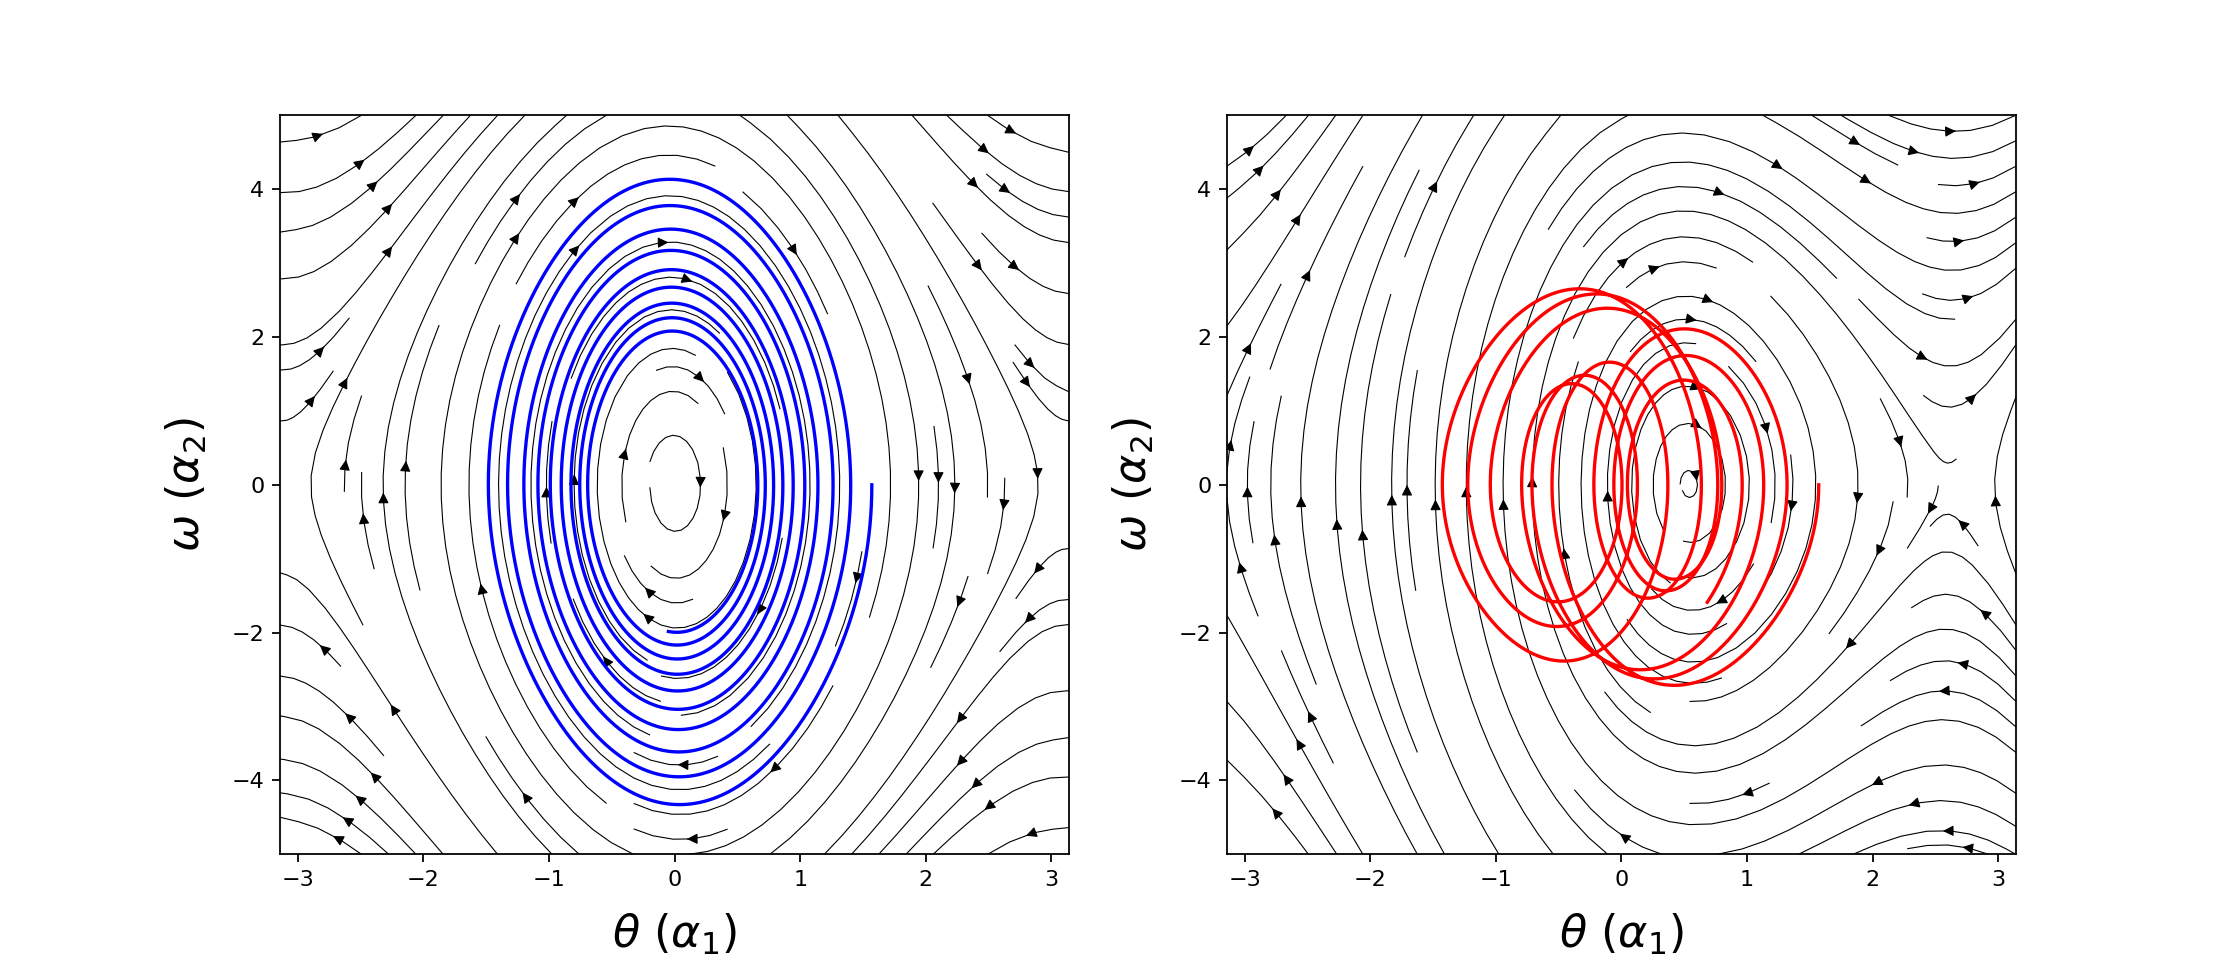

Text(0, 0.5, '$\\omega$ ($\\alpha_2$)')

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
b = 0.1
g = 9.8
L = 1.0

# Dynamics
def f_autonomous(x):
    x1, x2 = x
    dx1dt = x2
    dx2dt = -b * x2 - (g/L) * np.sin(x1)
    return np.array([dx1dt, dx2dt])

# Euler solver
def euler_autonomous(x0, t_grid):
    x = np.zeros((len(t_grid), 2))
    x[0] = x0
    dt = t_grid[1] - t_grid[0]  # time step
    for i in range(1, len(t_grid)):
        x[i] = x[i-1] + dt * f_autonomous(x[i-1])
    return x

def f_driven(x, t, A, omega):
    x1, x2 = x
    u = A * np.cos(omega * t)
    dx1dt = x2
    dx2dt = -b * x2 - (g/L) * np.sin(x1) + u  # fix for constant input and evolve traj - perf to raise concern..
    return np.array([dx1dt, dx2dt])

def euler_driven(x0, t_grid, A, omega):
    x = np.zeros((len(t_grid), 2))
    x[0] = x0
    dt = t_grid[1] - t_grid[0]
    for i in range(1, len(t_grid)):
        t = t_grid[i-1]
        x[i] = x[i-1] + dt * f_driven(x[i-1], t, A, omega)
    return x

# Input parameters
A = 5.0
omega = 1. # angular frequency

# Solve
t = np.linspace(0, 20, 10000) 
sol_euler_driven = euler_driven(x0, t, A, omega)

# Initial conditions and time grid
x0 = [np.pi/2, 0]  # Initial angle and angular velocity
t = np.linspace(0, 20, 10000)  # Need small Δt for Euler!
sol_euler_auto = euler_autonomous(x0, t)

# Parameters
b, g, L = 0.1, 9.8, 1.0
A, omega = 5.0, 1.0

# Grid for phase space
x1 = np.linspace(-np.pi, np.pi, 20)  # Angle θ ∈ [-π, π]
x2 = np.linspace(-5, 5, 20)          # Angular velocity ω ∈ [-2, 2]
X1, X2 = np.meshgrid(x1, x2)

# Input-driven flow field (snapshot at t=0)
U_driven = X2
V_driven = -b * X2 - (g/L) * np.sin(X1) + A * np.cos(omega * 0)

# Autonomous flow field
U_auto = X2
V_auto = -b * X2 - (g/L) * np.sin(X1)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Autonomous case
ax1.streamplot(X1, X2, U_auto, V_auto, color='k', density=1., linewidth=0.5)
ax2.streamplot(X1, X2, U_driven, V_driven, color='k', density=1., linewidth=0.5)
# Plot phase portrait
ax1.plot(sol_euler_auto[:, 0], sol_euler_auto[:, 1], label='Euler', color='blue')
ax2.plot(sol_euler_driven[:, 0], sol_euler_driven[:, 1], label='Euler', color="red")
ax1.set_xlabel(r'$\theta$ ($\alpha_1$)', fontsize=20, labelpad=10)
ax1.set_ylabel(r'$\omega$ ($\alpha_2$)', fontsize=20, labelpad=10)
ax2.set_xlabel(r'$\theta$ ($\alpha_1$)', fontsize=20, labelpad=10)
ax2.set_ylabel(r'$\omega$ ($\alpha_2$)', fontsize=20, labelpad=10)


# plt.tight_layout()
# fig.set_dpi(300)
# plt.show()

# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection='3d')

# # Compute u(t) for the driven system
# u = A * np.cos(omega * t)

# # Autonomous trajectory (z = 0, since u(t) = 0)
# ax.plot(sol_auto[:, 0], sol_auto[:, 1], np.zeros_like(t), 
#         label='Autonomous (u(t)=0)', linewidth=1, alpha=0.7)

# # Driven trajectory (z = u(t))
# ax.plot(sol_driven[:, 0], sol_driven[:, 1], u, 
#         label=f'Driven (u(t) = {A}cos({omega}t))', linewidth=1, alpha=0.7)

# ax.set_xlabel(r'$\theta$ ($\alpha_1$)', fontsize=20, labelpad=10)
# ax.set_ylabel(r'$\omega$ ($\alpha_2$)', fontsize=20, labelpad=10)
# ax.set_title('3D Phase Space: Input as Third Dimension')
# ax.legend()
# fig.set_dpi
# plt.show()

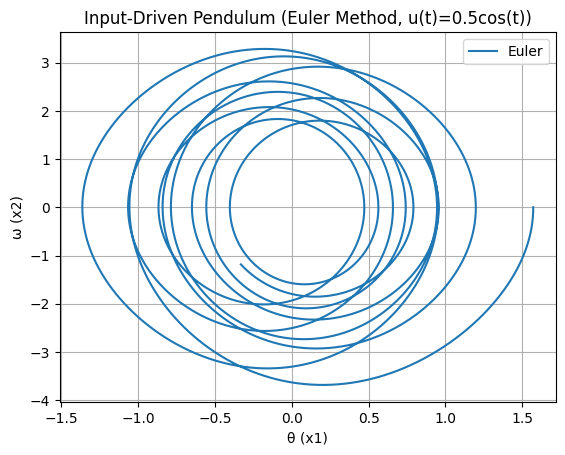

In [13]:
def f_driven(x, t, A, omega):
    x1, x2 = x
    u = A * np.cos(omega * t)
    dx1dt = x2
    dx2dt = -b * x2 - (g/L) * np.sin(x1) + u
    return np.array([dx1dt, dx2dt])

def euler_driven(x0, t_grid, A, omega):
    x = np.zeros((len(t_grid), 2))
    x[0] = x0
    dt = t_grid[1] - t_grid[0]
    for i in range(1, len(t_grid)):
        t = t_grid[i-1]
        x[i] = x[i-1] + dt * f_driven(x[i-1], t, A, omega)
    return x

# Input parameters
A = 2.0
omega = 1. # angular frequency

# Solve
sol_euler_driven = euler_driven(x0, t, A, omega)

# Plot phase portrait
plt.plot(sol_euler_driven[:, 0], sol_euler_driven[:, 1], label='Euler')
plt.xlabel('θ (x1)')
plt.ylabel('ω (x2)')
plt.title('Input-Driven Pendulum (Euler Method, u(t)=0.5cos(t))')
plt.grid()
plt.legend()
plt.show()

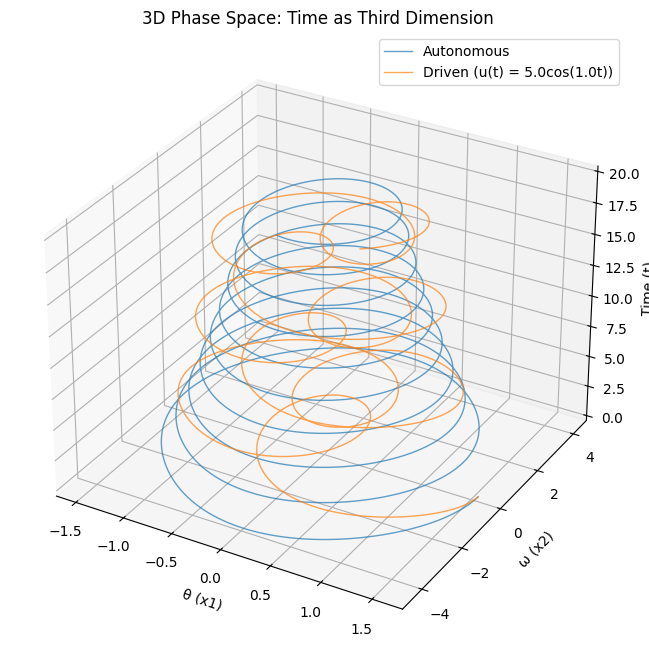

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters and initial conditions (same as before)
b, g, L = 0.1, 9.8, 1.0
A, omega = 5.0, 1.0
x0 = [np.pi/2, 0]
t = np.linspace(0, 20, 10000)

# Simulate autonomous and driven systems (2D)
sol_auto = euler_autonomous(x0, t)
sol_driven = euler_driven(x0, t, A, omega)

# Create 3D trajectories by adding time as the z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Autonomous trajectory (z = time)
ax.plot(sol_auto[:, 0], sol_auto[:, 1], t, 
        label='Autonomous', linewidth=1, alpha=0.7)

# Driven trajectory (z = time)
ax.plot(sol_driven[:, 0], sol_driven[:, 1], t, 
        label=f'Driven (u(t) = {A}cos({omega}t))', linewidth=1, alpha=0.7)

ax.set_xlabel('θ (x1)')
ax.set_ylabel('ω (x2)')
ax.set_zlabel('Time (t)')
ax.set_title('3D Phase Space: Time as Third Dimension')
ax.legend()
plt.show()

<IPython.core.display.Javascript object>


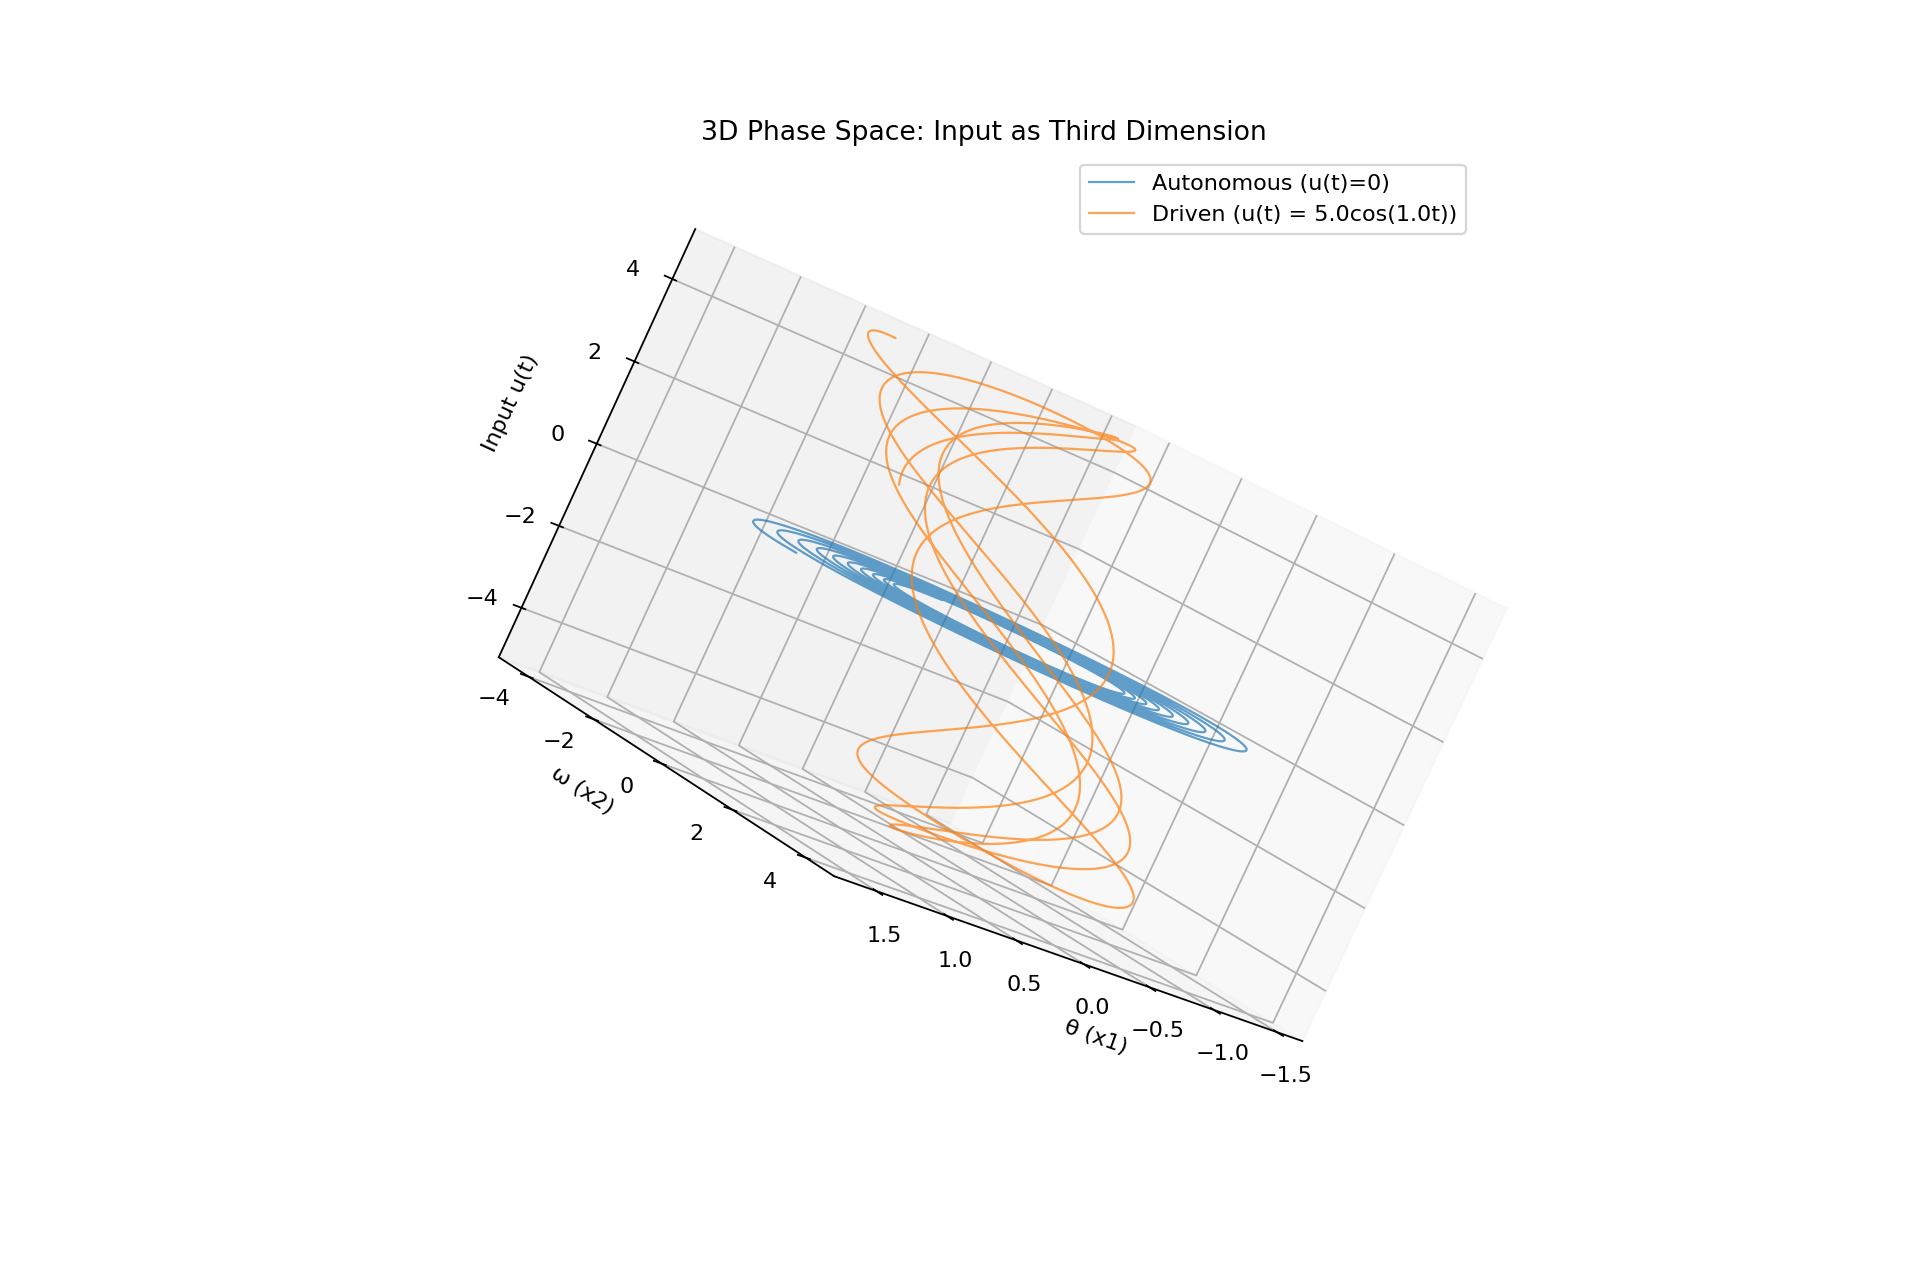

In [69]:
%matplotlib notebook

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Compute u(t) for the driven system
u = A * np.cos(omega * t)

# Autonomous trajectory (z = 0, since u(t) = 0)
ax.plot(sol_auto[:, 0], sol_auto[:, 1], np.zeros_like(t), 
        label='Autonomous (u(t)=0)', linewidth=1, alpha=0.7)

# Driven trajectory (z = u(t))
ax.plot(sol_driven[:, 0], sol_driven[:, 1], u, 
        label=f'Driven (u(t) = {A}cos({omega}t))', linewidth=1, alpha=0.7)

ax.set_xlabel('θ (x1)')
ax.set_ylabel('ω (x2)')
ax.set_zlabel('Input u(t)')
ax.set_title('3D Phase Space: Input as Third Dimension')
ax.legend()
fig.set_dpi
plt.show()

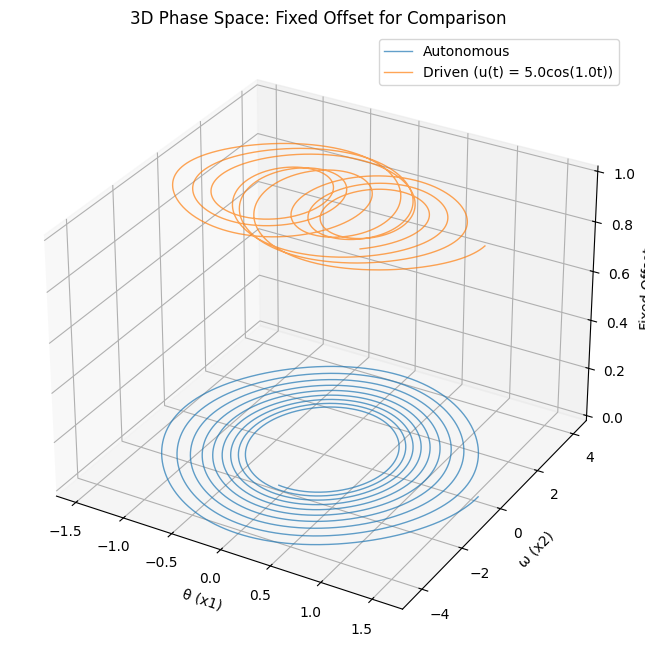

In [17]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Autonomous (z = 0)
ax.plot(sol_auto[:, 0], sol_auto[:, 1], np.zeros_like(t), 
        label='Autonomous', linewidth=1, alpha=0.7)

# Driven (z = 1)
ax.plot(sol_driven[:, 0], sol_driven[:, 1], np.ones_like(t), 
        label=f'Driven (u(t) = {A}cos({omega}t))', linewidth=1, alpha=0.7)

ax.set_xlabel('θ (x1)')
ax.set_ylabel('ω (x2)')
ax.set_zlabel('Fixed Offset')
ax.set_title('3D Phase Space: Fixed Offset for Comparison')
ax.legend()
plt.show()

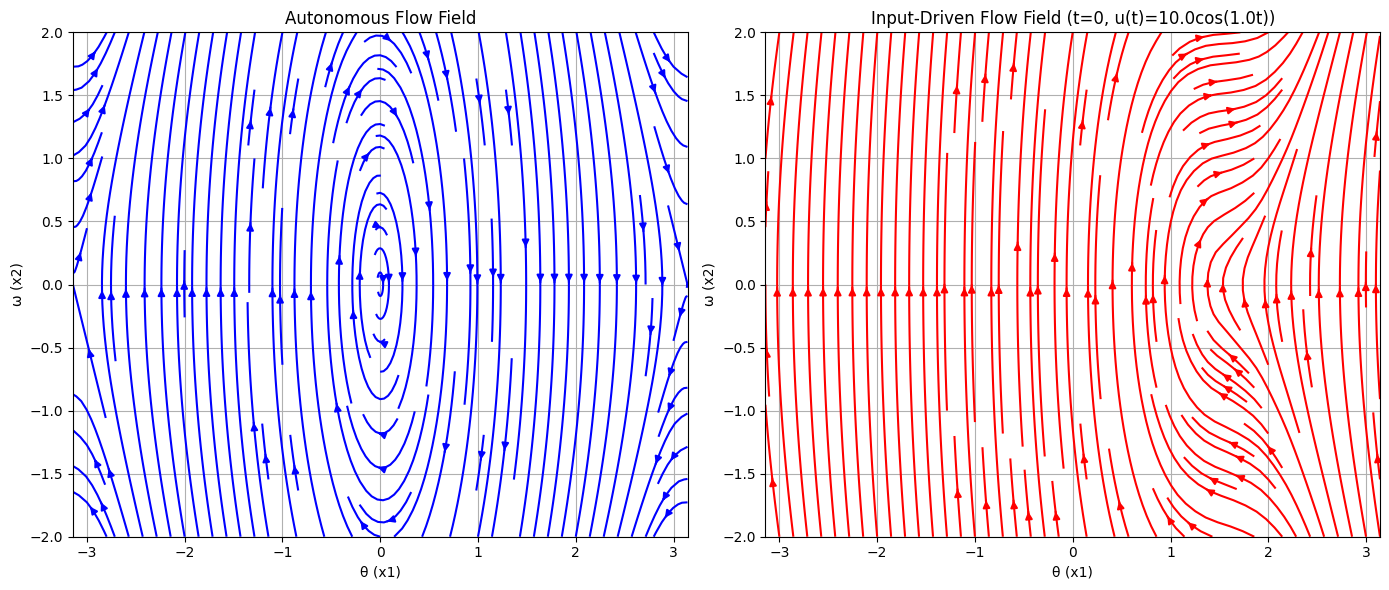

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
b, g, L = 0.1, 9.8, 1.0
A, omega = 10.0, 1.0

# Grid for phase space
x1 = np.linspace(-np.pi, np.pi, 20)  # Angle θ ∈ [-π, π]
x2 = np.linspace(-2, 2, 20)          # Angular velocity ω ∈ [-2, 2]
X1, X2 = np.meshgrid(x1, x2)

# Autonomous flow field
U_auto = X2
V_auto = -b * X2 - (g/L) * np.sin(X1)

# Input-driven flow field (snapshot at t=0)
U_driven = X2
V_driven = -b * X2 - (g/L) * np.sin(X1) + A * np.cos(omega * 0)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Autonomous case
ax1.streamplot(X1, X2, U_auto, V_auto, color='b', density=1.5)
ax1.set_title('Autonomous Flow Field')
ax1.set_xlabel('θ (x1)')
ax1.set_ylabel('ω (x2)')
ax1.grid()

# Input-driven case (t=0 snapshot)
ax2.streamplot(X1, X2, U_driven, V_driven, color='r', density=1.5)
ax2.set_title(f'Input-Driven Flow Field (t=0, u(t)={A}cos({omega}t))')
ax2.set_xlabel('θ (x1)')
ax2.set_ylabel('ω (x2)')
ax2.grid()

plt.tight_layout()
plt.show()

Using matplotlib backend: module://matplotlib_inline.backend_inline


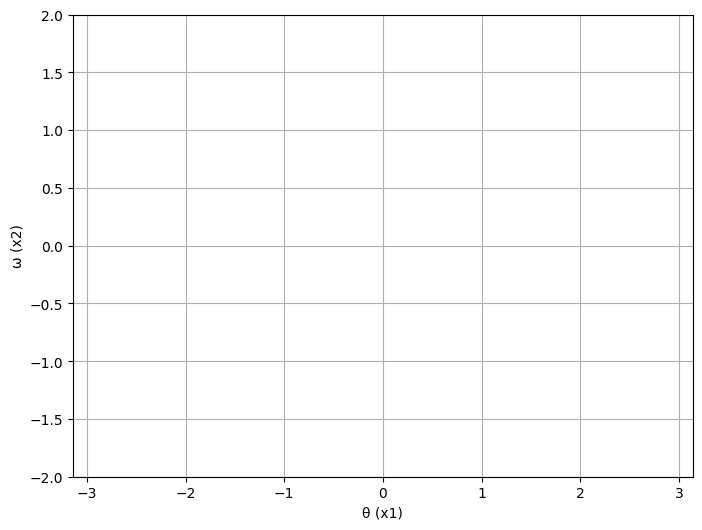

In [8]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-2, 2)
ax.set_xlabel('θ (x1)')
ax.set_ylabel('ω (x2)')
ax.grid()

def update(t):
    ax.clear()
    ax.set_title(f'Input-Driven Flow Field (t={t:.2f})')
    U = X2
    V = -b * X2 - (g/L) * np.sin(X1) + A * np.cos(omega * t)
    ax.streamplot(X1, X2, U, V, color='r', density=1.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-2, 2)

ani = FuncAnimation(fig, update, frames=np.linspace(0, 2*np.pi, 100), interval=100)
plt.show()

<IPython.core.display.Javascript object>


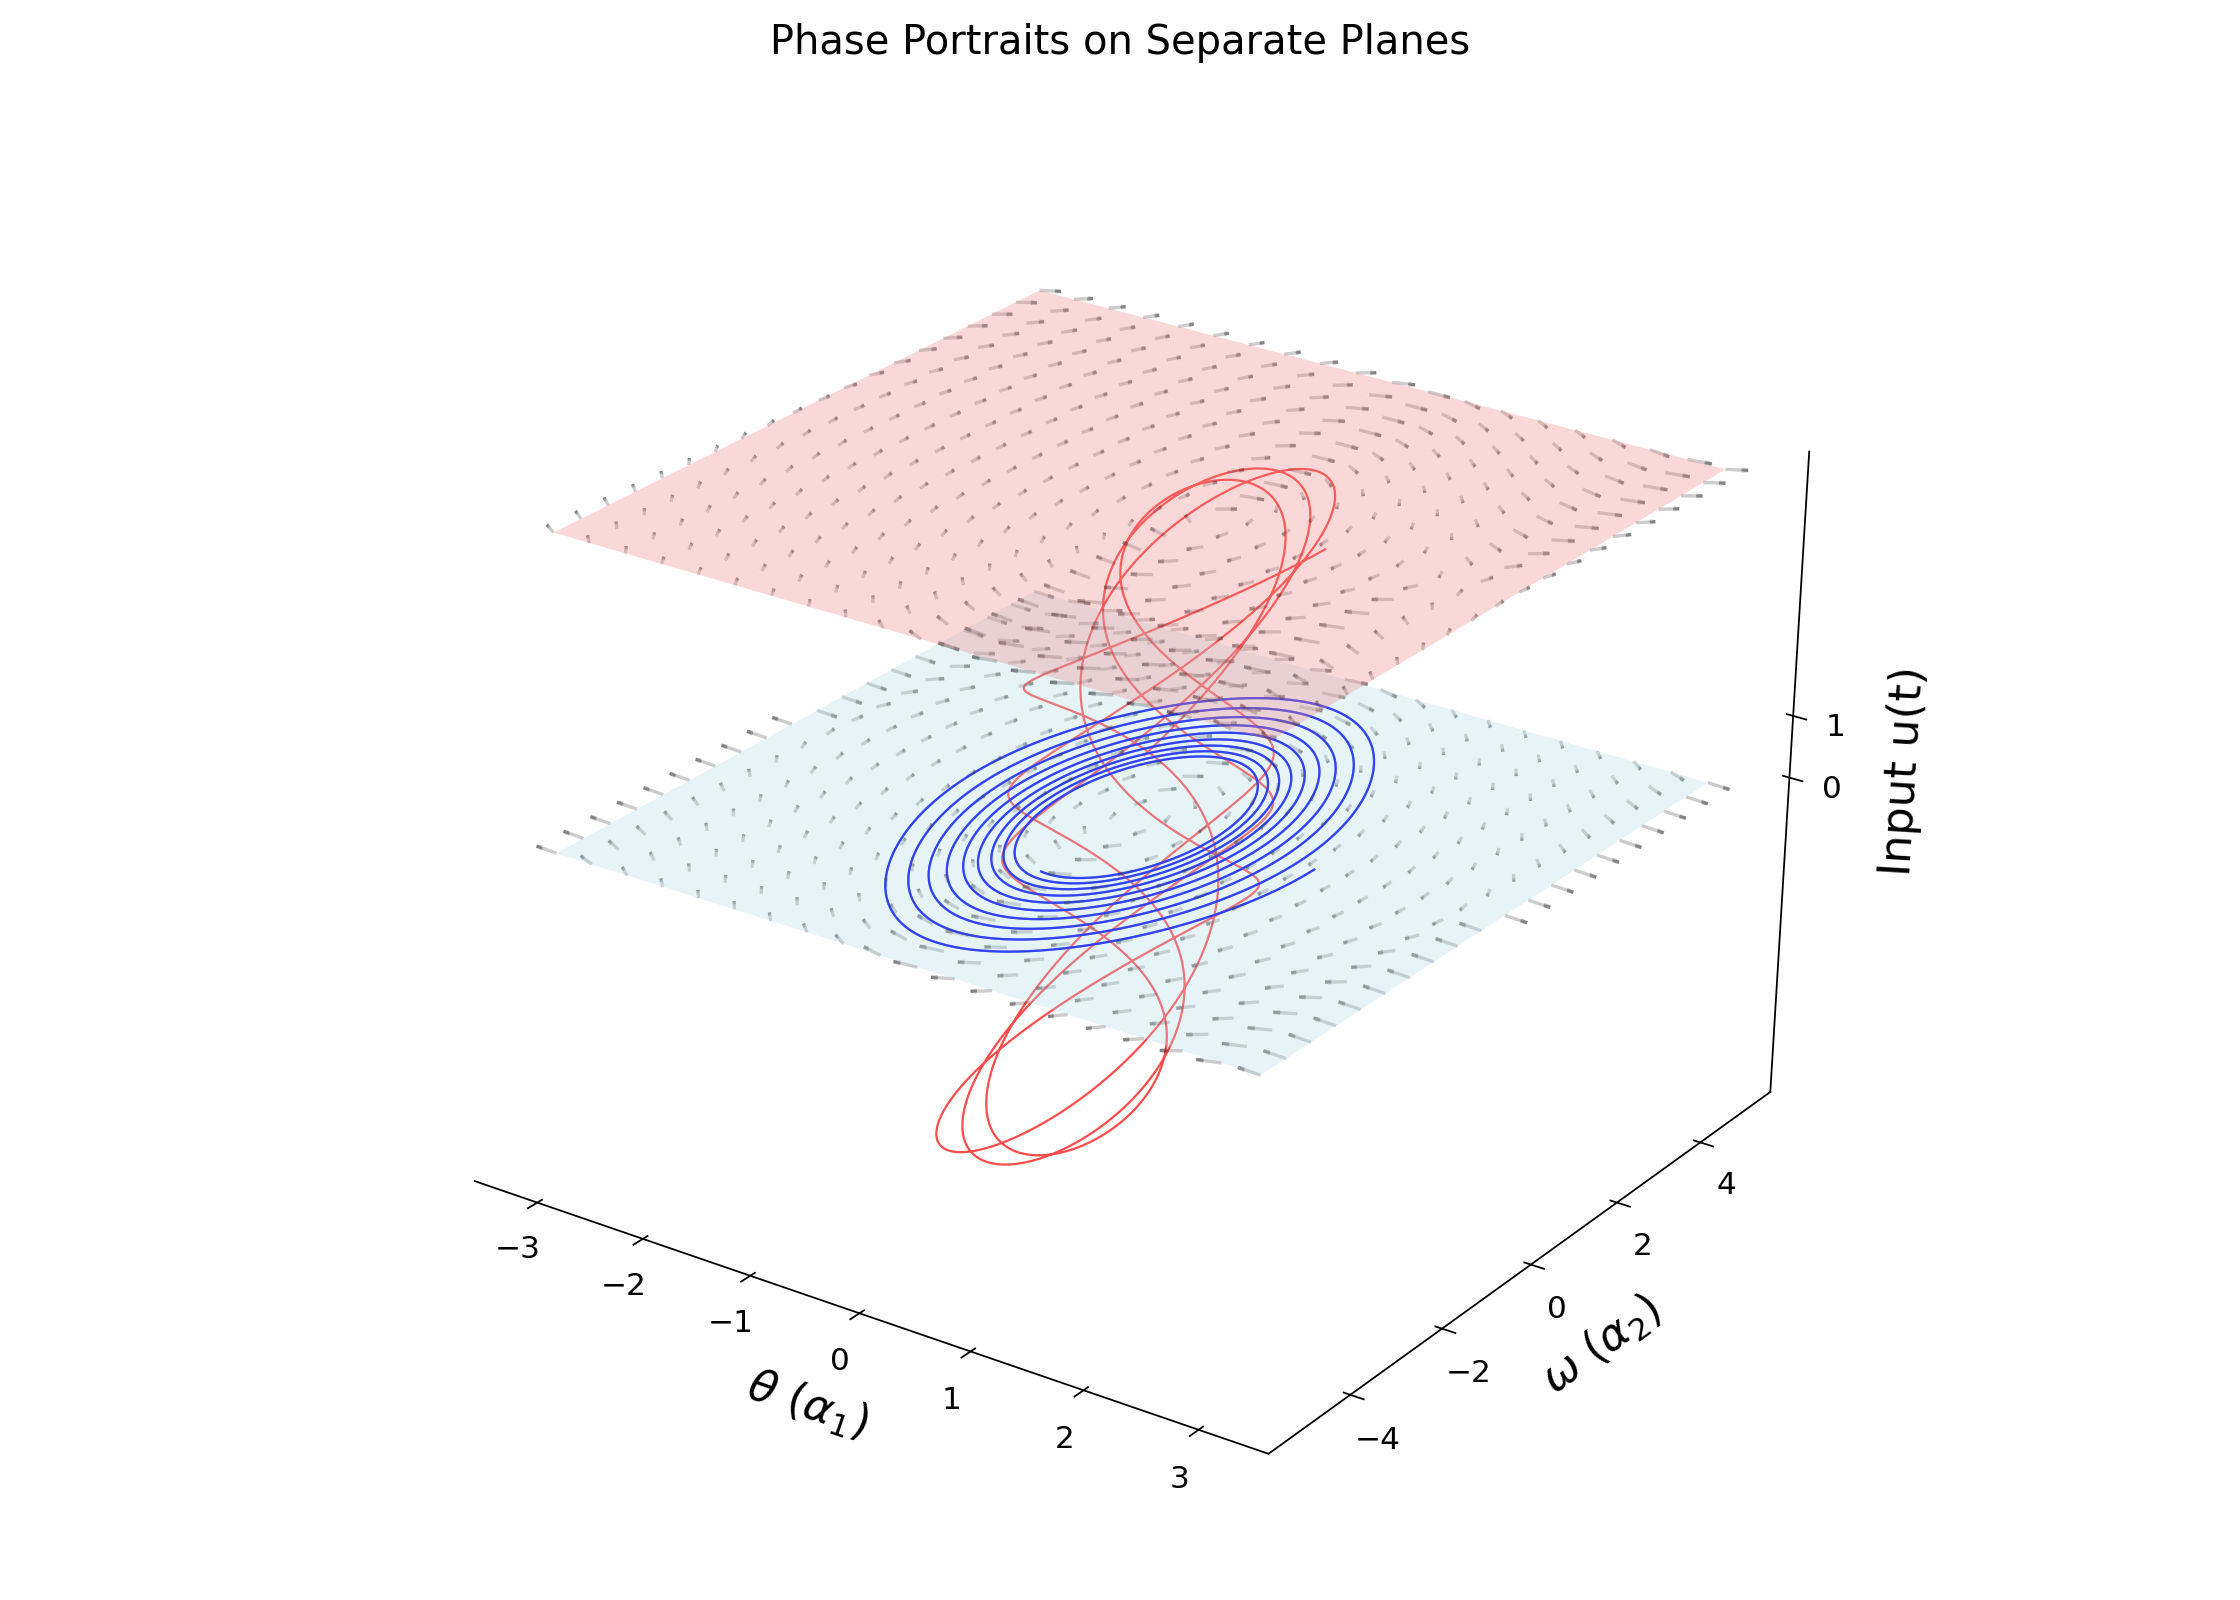

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
b, g, L = 0.1, 9.8, 1.0
A, omega = 5.0, 1.0

# Dynamics
def f_autonomous(x):
    x1, x2 = x
    dx1dt = x2
    dx2dt = -b * x2 - (g/L) * np.sin(x1)
    return np.array([dx1dt, dx2dt])

def f_driven(x, t, A, omega):
    x1, x2 = x
    u = A * np.cos(omega * t)
    dx1dt = x2
    dx2dt = -b * x2 - (g/L) * np.sin(x1) + u
    return np.array([dx1dt, dx2dt])

# Euler integrators
def euler_autonomous(x0, t_grid):
    x = np.zeros((len(t_grid), 2))
    x[0] = x0
    dt = t_grid[1] - t_grid[0]
    for i in range(1, len(t_grid)):
        x[i] = x[i-1] + dt * f_autonomous(x[i-1])
    return x

def euler_driven(x0, t_grid, A, omega):
    x = np.zeros((len(t_grid), 2))
    x[0] = x0
    dt = t_grid[1] - t_grid[0]
    for i in range(1, len(t_grid)):
        t = t_grid[i-1]
        x[i] = x[i-1] + dt * f_driven(x[i-1], t, A, omega)
    return x

# Initial condition and time
x0 = [np.pi/2, 0]
t = np.linspace(0, 20, 10000)

# Solve systems
sol_auto = euler_autonomous(x0, t)
sol_driven = euler_driven(x0, t, A, omega)

# Flow field grid
x1 = np.linspace(-np.pi, np.pi, 20)
x2 = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1, x2)

# Flow fields
U_auto = X2
V_auto = -b * X2 - (g/L) * np.sin(X1)
U_driven = X2
V_driven = -b * X2 - (g/L) * np.sin(X1) + A * np.cos(omega * 0)

# Plot 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.grid(False)

# Compute u(t) for the driven system
u = A * np.cos(omega * t)

# Autonomous trajectory (z = 0, since u(t) = 0)
ax.plot(sol_auto[:, 0], sol_auto[:, 1], np.zeros_like(t), 
        label='Autonomous (u(t)=0)', linewidth=1, alpha=0.7)

# Driven trajectory (z = u(t))
ax.plot(sol_driven[:, 0], sol_driven[:, 1], u, 
        label=f'Driven (u(t) = {A}cos({omega}t))', linewidth=1, alpha=0.7, color='red')

# Autonomous streamplot in 3D (z=0 plane)
ax.quiver(X1, X2, 0, U_auto, V_auto, 0, length=0.2, normalize=True, color='black', alpha=0.2)
ax.plot(sol_auto[:, 0], sol_auto[:, 1], zs=0, color='blue', label='Autonomous (z=0)', linewidth=1)

# Driven streamplot in 3D (z=1 plane)
ax.quiver(X1, X2, 5, U_driven, V_driven, 0, length=0.2, normalize=True, color='black', alpha=0.2)
#ax.plot(sol_driven[:, 0], sol_driven[:, 1], zs=1, color='red', label='Driven (z=1)', linewidth=1)

Z_auto = np.zeros_like(X1)
Z_driven = np.ones_like(X1)*5

# Colored planes
ax.plot_surface(X1, X2, Z_auto, color='lightblue', alpha=0.3, shade=False)
ax.plot_surface(X1, X2, Z_driven, color='lightcoral', alpha=0.3, shade=False)


# Labels and aesthetics
ax.set_xlabel(r'$\theta$ ($\alpha_1$)', fontsize=20, labelpad=10)
ax.set_ylabel(r'$\omega$ ($\alpha_2$)', fontsize=20, labelpad=10)
ax.set_zlabel('Input u(t)', fontsize=20, labelpad=10)
ax.tick_params(axis='both', labelsize=14)
ax.set_zticks([0, 1])
ax.set_title("Phase Portraits on Separate Planes", fontsize=18, pad=20)

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

plt.tight_layout()
plt.show()


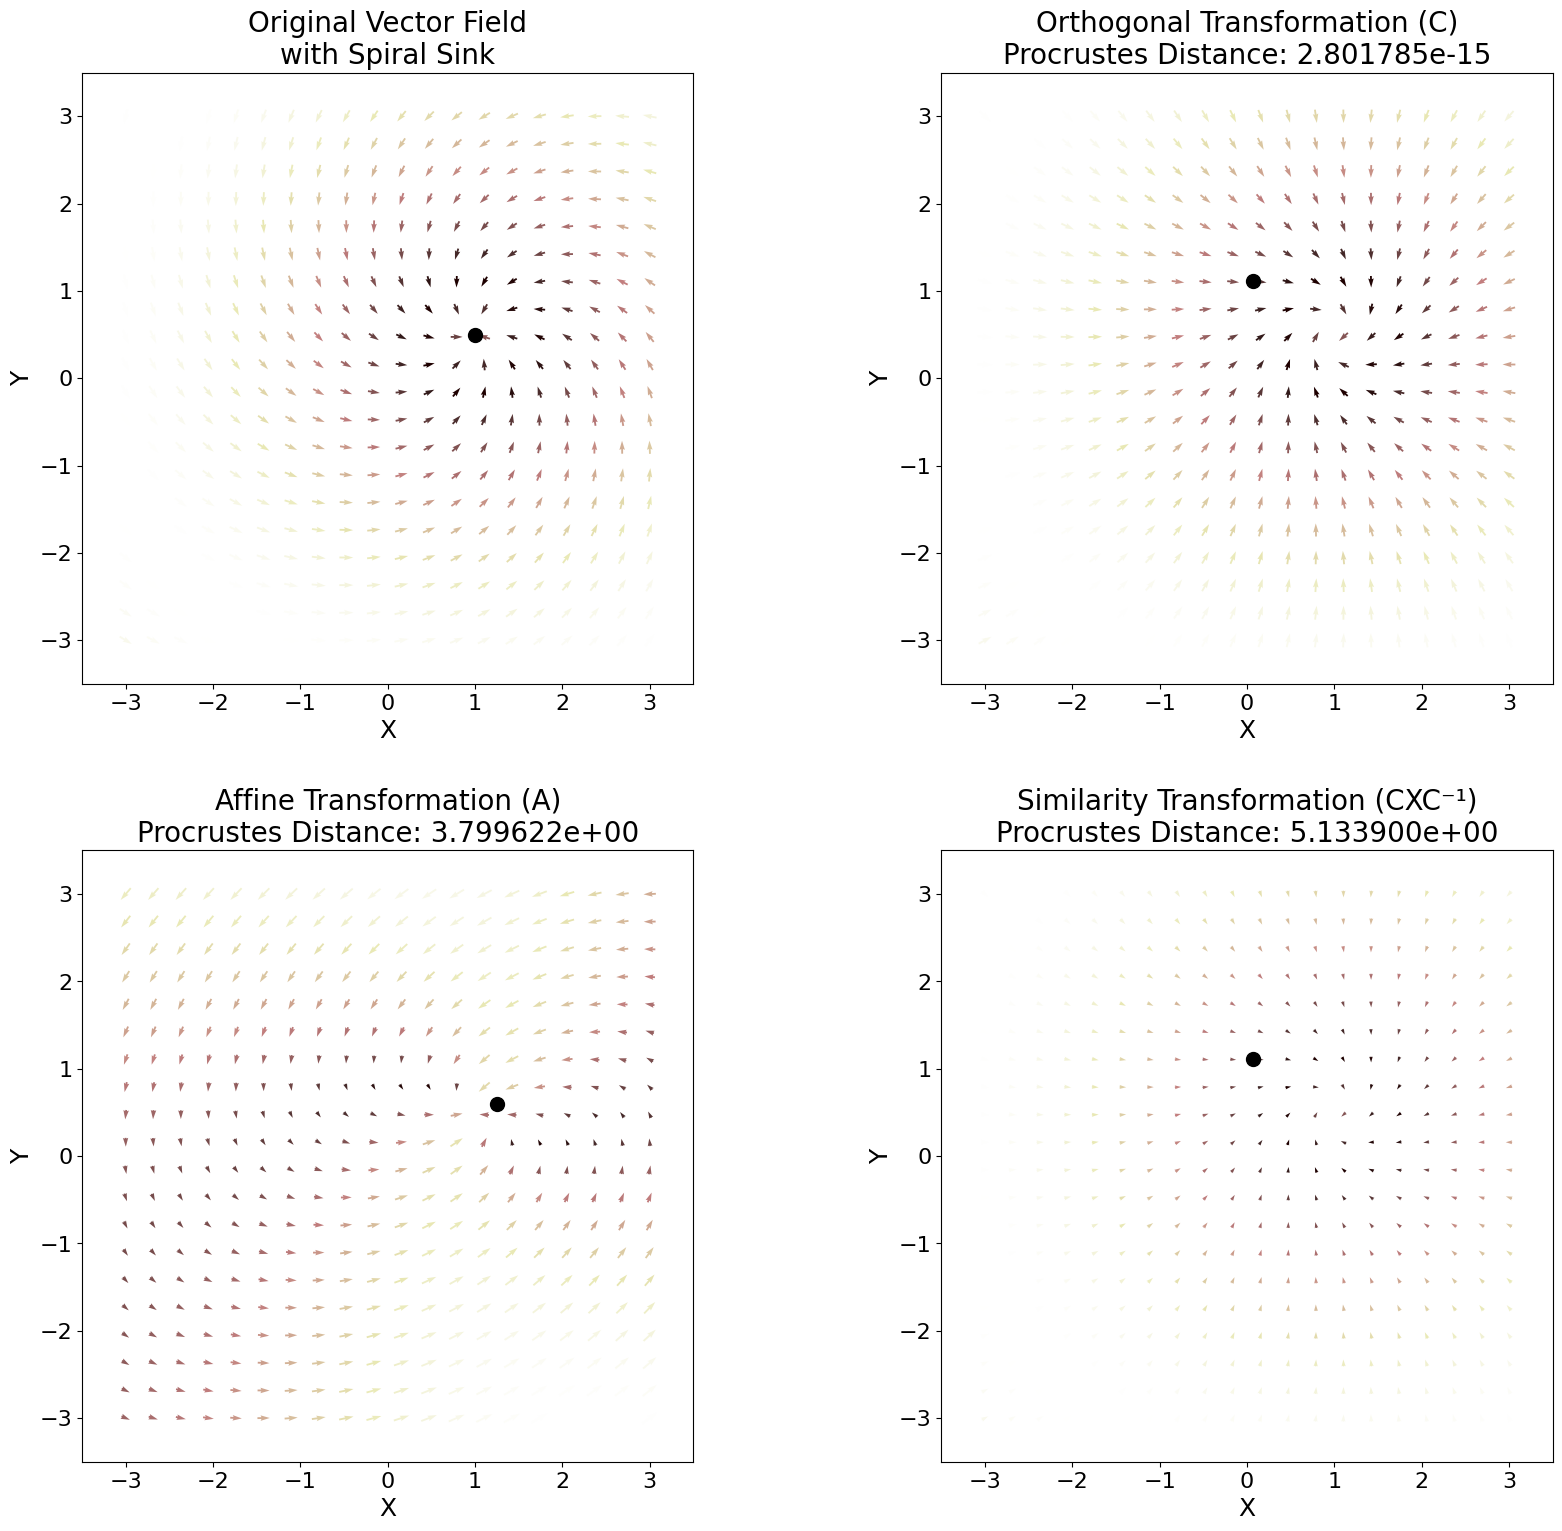

Procrustes distance for orthogonal transformation (C): 2.801785e-15
Procrustes distance for affine transformation (A): 3.799622e+00
Procrustes distance for similarity transformation (CXC⁻¹): 5.133900e+00


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from matplotlib.colors import Normalize
from matplotlib import cm
import matplotlib as mpl

# Increase font size globally
plt.rcParams.update({'font.size': 16})

# Define a vector field with a proper sink
def vector_field(x, y):
    """Define a vector field with a proper sink at (1.0, 0.5)."""
    # Sink location
    sink_x = 1.0
    sink_y = 0.5
    
    # Vector from each point to the sink
    dx = sink_x - x
    dy = sink_y - y
    
    # Distance to sink (add small epsilon to avoid division by zero)
    dist = np.sqrt(dx**2 + dy**2) + 1e-10
    
    # Normalize to create a sink with magnitude decreasing with distance
    strength = 0.5 * np.exp(-0.2 * dist)
    
    # Add a rotational component to make it more interesting
    rot_strength = 0.3 * np.exp(-0.2 * dist)
    rot_dx = -rot_strength * (y - sink_y)
    rot_dy = rot_strength * (x - sink_x)
    
    # Combine components
    final_dx = strength * dx / dist + rot_dx
    final_dy = strength * dy / dist + rot_dy
    
    return final_dx, final_dy

# Create a grid for the vector field
x = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x, y)

# Calculate vector field values
U, V = vector_field(X, Y)
M = np.sqrt(U**2 + V**2)  # Vector magnitudes for coloring

# Define transformations

# 1. Orthogonal transformation (rotation matrix)
theta = np.pi/3  # 60 degrees rotation
C = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
C_inv = C.T  # For orthogonal matrices, inverse = transpose

# 2. Affine transformation (combination of shear, scale, and translation)
A = np.array([
    [1.0, 0.5],  # Shear and scale
    [0.2, 0.8]   # Non-orthogonal transformation
])
b = np.array([0.5, -0.3])  # Translation vector

# Apply orthogonal transformation to the vector field
U_orthogonal = U * C[0, 0] + V * C[0, 1]
V_orthogonal = U * C[1, 0] + V * C[1, 1]
M_orthogonal = np.sqrt(U_orthogonal**2 + V_orthogonal**2)

# Apply affine transformation to the vector field
# For vector field, we only apply the linear part (A), not the translation (b)
U_affine = U * A[0, 0] + V * A[0, 1]
V_affine = U * A[1, 0] + V * A[1, 1]
M_affine = np.sqrt(U_affine**2 + V_affine**2)

# Apply similarity transformation CXC^(-1)
# For each grid point (x,y), we:
# 1. Create a matrix X representing our vector field at that point
# 2. Apply the similarity transformation CXC^(-1)
# 3. Extract the transformed vector components

# For a vector field, we can represent the linearized dynamics at each point as a Jacobian matrix
# Here we'll create a simplified version using the vector components
U_similarity = np.zeros_like(U)
V_similarity = np.zeros_like(V)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Create a matrix representation of the vector field at this point
        X_matrix = np.array([[U[i,j], 0], [V[i,j], 0]])
        
        # Apply similarity transformation CXC^(-1)
        X_transformed = C @ X_matrix @ C_inv
        
        # Extract the transformed vector components
        U_similarity[i,j] = X_transformed[0,0]
        V_similarity[i,j] = X_transformed[1,0]

M_similarity = np.sqrt(U_similarity**2 + V_similarity**2)

# Define Procrustes distance and alignment function
def procrustes_align_and_distance(X, Y):
    """Compute the Procrustes distance between two matrices and return aligned Y."""
    # Center the matrices
    X_centered = X - np.mean(X, axis=0)
    Y_centered = Y - np.mean(Y, axis=0)
    
    # Compute the optimal orthogonal transformation
    R, s = orthogonal_procrustes(Y_centered, X_centered)
    
    # Apply the transformation to Y
    Y_aligned = Y_centered @ R
    
    # Compute the Frobenius norm of the difference
    distance = np.sqrt(np.sum((X_centered - Y_aligned) ** 2))
    
    return distance, X_centered, Y_aligned

# For vector fields, create matrices from the grid points and their vectors
vectors = np.column_stack((U.flatten(), V.flatten()))
vectors_orthogonal = np.column_stack((U_orthogonal.flatten(), V_orthogonal.flatten()))
vectors_affine = np.column_stack((U_affine.flatten(), V_affine.flatten()))
vectors_similarity = np.column_stack((U_similarity.flatten(), V_similarity.flatten()))

# Calculate Procrustes distances
proc_dist_orthogonal, _, _ = procrustes_align_and_distance(vectors, vectors_orthogonal)
proc_dist_affine, _, _ = procrustes_align_and_distance(vectors, vectors_affine)
proc_dist_similarity, _, _ = procrustes_align_and_distance(vectors, vectors_similarity)

# Create the plot with 4 subplots (2 rows x 2 columns)
fig, axs = plt.subplots(2, 2, figsize=(18, 16))
axs = axs.flatten()  # Flatten to make indexing easier

# Create a pink colormap
pink_cmap = plt.cm.pink

# Mark the sink location in all plots
sink_x, sink_y = 1.0, 0.5

# Plot 1: Original vector field
axs[0].quiver(X, Y, U, V, M, cmap=pink_cmap, pivot='mid', scale=25)
axs[0].plot(sink_x, sink_y, 'ko', markersize=10)  # Mark the sink
axs[0].set_title("Original Vector Field\nwith Spiral Sink", fontsize=20)
axs[0].set_xlabel("X", fontsize=18)
axs[0].set_ylabel("Y", fontsize=18)
axs[0].set_aspect('equal')
axs[0].set_xlim(-3.5, 3.5)
axs[0].set_ylim(-3.5, 3.5)

# Plot 2: Vector field after orthogonal transformation
# Transform the sink location
sink_orthogonal_x = sink_x * C[0, 0] + sink_y * C[0, 1]
sink_orthogonal_y = sink_x * C[1, 0] + sink_y * C[1, 1]

axs[1].quiver(X, Y, U_orthogonal, V_orthogonal, M_orthogonal, cmap=pink_cmap, pivot='mid', scale=25)
axs[1].plot(sink_orthogonal_x, sink_orthogonal_y, 'ko', markersize=10)  # Mark the transformed sink
axs[1].set_title(f"Orthogonal Transformation (C)\nProcrustes Distance: {proc_dist_orthogonal:.6e}", fontsize=20)
axs[1].set_xlabel("X", fontsize=18)
axs[1].set_ylabel("Y", fontsize=18)
axs[1].set_aspect('equal')
axs[1].set_xlim(-3.5, 3.5)
axs[1].set_ylim(-3.5, 3.5)

# Plot 3: Vector field after affine transformation
# Transform the sink location
sink_affine_x = sink_x * A[0, 0] + sink_y * A[0, 1]
sink_affine_y = sink_x * A[1, 0] + sink_y * A[1, 1]

axs[2].quiver(X, Y, U_affine, V_affine, M_affine, cmap=pink_cmap, pivot='mid', scale=25)
axs[2].plot(sink_affine_x, sink_affine_y, 'ko', markersize=10)  # Mark the transformed sink
axs[2].set_title(f"Affine Transformation (A)\nProcrustes Distance: {proc_dist_affine:.6e}", fontsize=20)
axs[2].set_xlabel("X", fontsize=18)
axs[2].set_ylabel("Y", fontsize=18)
axs[2].set_aspect('equal')
axs[2].set_xlim(-3.5, 3.5)
axs[2].set_ylim(-3.5, 3.5)

# Plot 4: Vector field after similarity transformation CXC^(-1)
# For similarity transformation, the sink location is transformed like in orthogonal
axs[3].quiver(X, Y, U_similarity, V_similarity, M_similarity, cmap=pink_cmap, pivot='mid', scale=25)
axs[3].plot(sink_orthogonal_x, sink_orthogonal_y, 'ko', markersize=10)  # Mark the transformed sink
axs[3].set_title(f"Similarity Transformation (CXC⁻¹)\nProcrustes Distance: {proc_dist_similarity:.6e}", fontsize=20)
axs[3].set_xlabel("X", fontsize=18)
axs[3].set_ylabel("Y", fontsize=18)
axs[3].set_aspect('equal')
axs[3].set_xlim(-3.5, 3.5)
axs[3].set_ylim(-3.5, 3.5)

# Remove grid from all subplots
for i in range(4):
    axs[i].grid(False)

plt.tight_layout(pad=2.0)
plt.savefig('vector_field_proper_sink.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Procrustes distance for orthogonal transformation (C): {proc_dist_orthogonal:.6e}")
print(f"Procrustes distance for affine transformation (A): {proc_dist_affine:.6e}")
print(f"Procrustes distance for similarity transformation (CXC⁻¹): {proc_dist_similarity:.6e}")

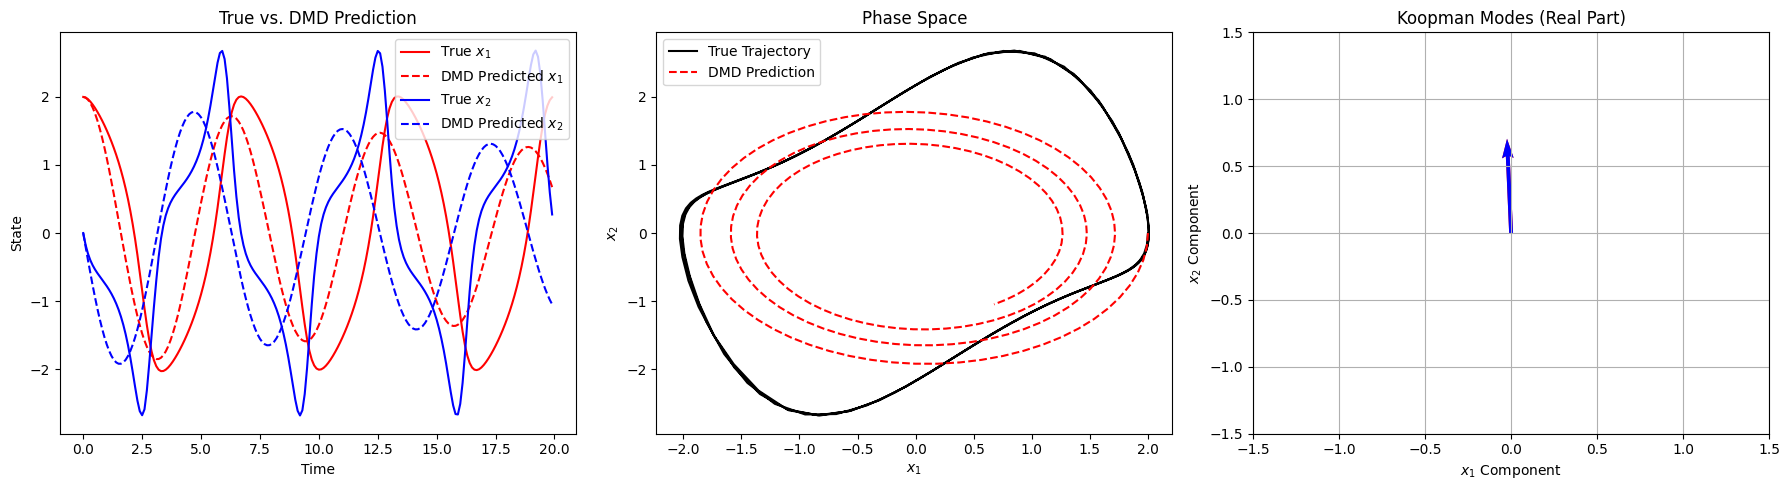

Koopman Eigenvalues: [0.99261092+0.0994229j 0.99261092-0.0994229j]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import svd, eig

# 1. Define the 2D Van der Pol oscillator
def van_der_pol(t, x, mu=1.0):
    return [x[1], mu * (1 - x[0]**2) * x[1] - x[0]]

# 2. Generate trajectory data
dt = 0.1
t_span = [0, 20]
x0 = [2.0, 0.0]  # Initial condition
sol = solve_ivp(van_der_pol, t_span, x0, t_eval=np.arange(t_span[0], t_span[1], dt))
X = sol.y  # Shape (2, n_timesteps)

# 3. DMD implementation from scratch
def dmd(X, rank=2):
    # Split data into X (t) and X' (t+1)
    X1, X2 = X[:, :-1], X[:, 1:]
    
    # SVD of X1
    U, s, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]  # Truncate to rank
    Sigma_r_inv = np.diag(1.0 / s[:rank])
    Vh_r = Vh[:rank, :]
    
    # Compute A_tilde (reduced DMD matrix)
    A_tilde = U_r.T @ X2 @ Vh_r.T @ Sigma_r_inv
    
    # Eigen decomposition of A_tilde
    eigvals, eigvecs = eig(A_tilde)
    modes = X2 @ Vh_r.T @ Sigma_r_inv @ eigvecs  # DMD modes
    
    return modes, eigvals

# 4. Run DMD
modes, eigenvalues = dmd(X)

# 5. Predict future states
def dmd_predict(X_init, modes, eigenvalues, n_steps):
    # Initial amplitudes (projection onto modes)
    b = np.linalg.pinv(modes) @ X_init
    # Time evolution
    t = np.arange(n_steps)
    dynamics = np.array([b * (eigenvalues**step) for step in t])
    return (modes @ dynamics.T).T

X_pred = dmd_predict(X[:, 0], modes, eigenvalues, len(sol.t))

# 6. Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# (a) True vs. Predicted Trajectory
ax1.plot(sol.t, X[0, :], 'r-', label='True $x_1$')
ax1.plot(sol.t, X_pred[:, 0].real, 'r--', label='DMD Predicted $x_1$')
ax1.plot(sol.t, X[1, :], 'b-', label='True $x_2$')
ax1.plot(sol.t, X_pred[:, 1].real, 'b--', label='DMD Predicted $x_2$')
ax1.set_xlabel('Time')
ax1.set_ylabel('State')
ax1.legend()
ax1.set_title('True vs. DMD Prediction')

# (b) Phase Space
ax2.plot(X[0, :], X[1, :], 'k-', label='True Trajectory')
ax2.plot(X_pred[:, 0].real, X_pred[:, 1].real, 'r--', label='DMD Prediction')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.legend()
ax2.set_title('Phase Space')

# (c) Koopman Modes Visualization
ax3.quiver([0, 0], [0, 0], modes[0, :].real, modes[1, :].real,
           angles='xy', scale_units='xy', scale=1, color=['r', 'b'])
ax3.set_xlim(-1.5, 1.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_xlabel('$x_1$ Component')
ax3.set_ylabel('$x_2$ Component')
ax3.set_title('Koopman Modes (Real Part)')
ax3.grid()

plt.tight_layout()
plt.show()

# Print Eigenvalues
print("Koopman Eigenvalues:", eigenvalues)